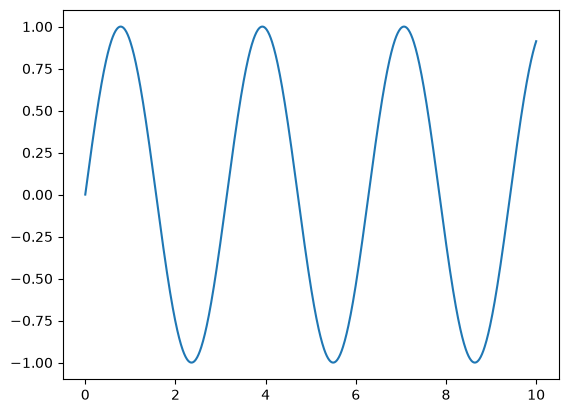

In [1]:
import jax.numpy as jnp # JAX is designed to be similar to numpy for convenience

# for instance:
import matplotlib.pyplot as plt

x_jnp = jnp.linspace(0, 10, 1000)
y_jnp = 2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)
plt.plot(x_jnp, y_jnp)


# the only thing that changes is np -> jnp

In [3]:
# However JAX arrays are different representations to Numpy arrays:

import numpy as np
import jax.numpy as jnp

x_np = np.linspace(0, 10, 1000)
x_jnp = jnp.linspace(0, 10, 1000)

type(x_np), type(x_jnp)

(numpy.ndarray, jaxlib._jax.ArrayImpl)

In [4]:
# this translates into one main difference between JAX and Numpy arrays.
# JAX arrays are IMMUTABLE:

#numpy
x = np.arange(10)
x[0] = 10
print(x)

#jax
%xmode minimal
x = jnp.arange(10)
x[0] = 10


[10  1  2  3  4  5  6  7  8  9]
Exception reporting mode: Minimal


TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

In [5]:
#instead, do this:

y = x.at[0].set(10)
print(x)
print(y)

[0 1 2 3 4 5 6 7 8 9]
[10  1  2  3  4  5  6  7  8  9]


In [7]:
# JAX lets you inspect where the contents of an array are stored in memory

x.devices() # CPU

# in general an array maight be sharded across multiple devices:

x.sharding

SingleDeviceSharding(device=CpuDevice(id=0), memory_kind=device)

**Just-in-time (JIT) Compilation**

\begin{itemize}
    \item by default JAX executes operations one at a time
    \item using a JIT compiler, sequences of operations can be optimized together and run at once
    \item not all JAX code can be JIT compiled: requires static and known (at the time) array shapes
\end{itemize}

In [15]:
import jax.numpy as jnp

def norm(X):
    X = X - X.mean(axis=0)
    return X / X.std(axis=0)

#   JIT version
from jax import jit
norm_compiled = jit(norm)

# this function returns the same result as the original up to standard floating-point accuracy:
np.random.seed(6541)
X = jnp.array(np.random.rand(10000, 10))
np. allclose(norm(X), norm_compiled(X), atol=1e-6)

# the piont is that JIT operations run way faster than normal operations that haven't yet been compiled
%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

451 μs ± 54.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
517 μs ± 68.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [10]:
# the piont is that JIT operations run way faster than normal operations that haven't yet been compiled

%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

593 μs ± 30.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
631 μs ± 102 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
# some JAX operations aren't JIT-compilable, as it requires arrays to have static shapes

def get_negatives(x):
    return x[x < 0]

x = jnp.array(np.random.randn(10))
get_negatives(x)

Array([-0.07036903, -1.1875622 , -0.4127037 , -0.49008432, -0.89755416,
       -2.1313696 ], dtype=float32)

In [17]:
# but in JIT mode:
jit(get_negatives)(x)

# outputs error message because the function generates an array whose shape in unknown at compile time
# (the size of the output depends on the values of the input array)

NonConcreteBooleanIndexError: Array boolean indices must be concrete; got bool[10]

See https://docs.jax.dev/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError

**Derivatives**

In [20]:
# jax.grad performs automatic differentiation (autodiff)
from jax import grad

def sum_logistic(x):
    return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

x_small = jnp.arange(3.)
derivative_fn = grad(sum_logistic)
print(derivative_fn(x_small))

# verify with finite differences:
def first_finite_differences(f, x, eps=1e-3):
    return jnp.array([(f(x + eps * v) - f(x - eps * v)) / (2 * eps) for v in jnp.eye(len(x))])

print(first_finite_differences(sum_logistic, x_small))

[0.25       0.19661197 0.10499357]
[0.24998187 0.1964569  0.10502338]


In [21]:
# grad and jit can be composed arbitrarily
print(grad(jit(grad(jit(grad(sum_logistic)))))(1.0))

-0.0353256


In [22]:
# for vector function, use Jacobian:
from jax import jacobian
print(jacobian(jnp.exp)(x_small))

[[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


In [23]:
# other useful JAX autodiff operations:
from jax import jacfwd, jacrev

def hessian(fun):
    return jit(jacfwd(jacrev(fun)))

print(hessian(sum_logistic)(x_small))

[[-0.         -0.         -0.        ]
 [-0.         -0.09085776 -0.        ]
 [-0.         -0.         -0.07996249]]


**Auto-Vectorization**

In [28]:
from jax import random

key = random.key(5748)
key1, key2 = random.split(key)
mat = random.normal(key1, (150, 100))
batched_x = random.normal(key2, (10, 100))

def apply_matrix(x):
    return jnp.dot(mat, x)


# but what if we want to apply the same matrix to a batch of vectors instead of just 1?

#NAIVE IMPLEMENTATION
def naively_batched_apply_matrix(v_batched):
    return jnp.stack([apply_matrix(v) for v in v_batched])
print('Naively batched')
%timeit naively_batched_apply_matrix(batched_x).block_until_ready()

# MANUAL VECTORIZATION
import numpy as np

@jit
def batched_apply_matrix(batched_x):
    return jnp.dot(batched_x, mat.T)

    np.testing.assert_allclose(naively_batched_apply_matrix(batched_x), batched_apply_matrix(batched_x), atol=1e-4, rtol=1e-4)

print('Manually batched')
%timeit batched_apply_matrix(batched_x).block_until_ready()

# however this is too simplistic and will get harder for more complex functions
# jax.vmap is designed to automatically transform a function into a batch-aware version

# WITH VMAP
from jax import vmap

@jit
def vmap_batched_apply_matrix(batched_x):
    return vmap(apply_matrix)(batched_x)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x), vmap_batched_apply_matrix(batched_x), atol=1e-4, rtol=1e-4)
print('Vmap batched')
%timeit vmap_batched_apply_matrix(batched_x).block_until_ready()

Naively batched
535 μs ± 41 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Manually batched
47.3 μs ± 4.19 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Vmap batched
78.9 μs ± 7.86 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
